In this workflow we need 3 LLMs generator, evaluator, Optimizer llm who are expert in their work like GPT 4.5(good writing capability) for generator etc

In [52]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict, Literal, Annotated
from langchain_core.messages import SystemMessage, HumanMessage
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import operator

In [53]:
load_dotenv()

generator_llm = ChatGroq(model="openai/gpt-oss-120b")
evaluator_llm = ChatGroq(model="openai/gpt-oss-120b")
optimizer_llm = ChatGroq(model="openai/gpt-oss-120b")


In [54]:
class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "need_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [55]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [56]:
class TweetState(TypedDict):

    topic: str
    tweet: str
    evaluation: Literal['approved', "need_improvement"]
    feedback: str
    iteration: int
    max_iter: int

    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]
    


In [57]:
def generate(state: TweetState):

    # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
        Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

        Rules:
        - Do NOT use question-answer format.
        - Max 280 characters.
        - Use observational humor, irony, sarcasm, or cultural references.
        - Think in meme logic, punchlines, or relatable takes.
        - Use simple, day to day english
        """)
    ]

    # send generator_llm
    response = generator_llm.invoke(messages).content

    # return response
    return {'tweet': response, 'tweet_history': [response]}


def evaluate(state: TweetState):
    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
        Evaluate the following tweet:

        Tweet: "{state['tweet']}"

        Use the criteria below to evaluate the tweet:

        1. Originality – Is this fresh, or have you seen it a hundred times before?  
        2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
        3. Punchiness – Is it short, sharp, and scroll-stopping?  
        4. Virality Potential – Would people retweet or share it?  
        5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

        Auto-reject if:
        - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
        - It exceeds 280 characters
        - It reads like a traditional setup-punchline joke
        - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

        ### Respond ONLY in structured format:
        - evaluation: "approved" or "need_improvement"  
        - feedback: One paragraph explaining the strengths and weaknesses 
        """)
        ]

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

def optimize(state: TweetState):
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

def check_cond(state: TweetState):
    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iter']:
        return 'approved'
    else:
        return 'need_improvement'

In [58]:
graph = StateGraph(TweetState)

graph.add_node('generate', generate)
graph.add_node('evaluate', evaluate)
graph.add_node('optimize', optimize)

graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')
graph.add_conditional_edges('evaluate', check_cond, {'approved': END, 'need_improvement': 'optimize'})
graph.add_edge('optimize', 'evaluate')

workflow = graph.compile()



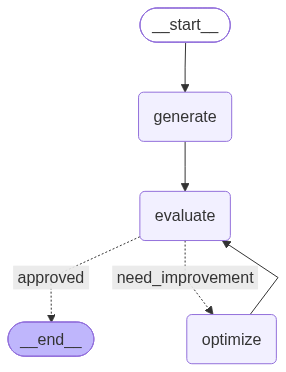

In [59]:
workflow

In [62]:
initial_state = {
    "topic" : "Earth",
    "iteration": 1,
    "max_iter": 5
}
workflow.invoke(initial_state)


{'topic': 'Earth',
 'tweet': 'Earth: the only planet that lets you complain about traffic, blame the climate for it, and still wonder why your Wi‑Fi drops during a meteor shower. #PlanetProblems 🌍🚗📡',
 'evaluation': 'approved',
 'feedback': 'The tweet feels fresh enough—mixing traffic woes, climate blame, and the oddly specific Wi‑Fi‑drop‑during‑meteor‑shower gag gives it a novel spin. It lands a genuine chuckle through its witty juxtaposition, and while it’s a tad on the longer side, it stays concise and scroll‑stopping. The hashtag #PlanetProblems plus emojis boost shareability, making it ripe for retweets. Overall it meets the format rules and checks all the boxes for originality, humor, punchiness, and virality potential.',
 'iteration': 1,
 'max_iter': 5,
 'tweet_history': ['Earth: the only planet that lets you complain about traffic, blame the climate for it, and still wonder why your Wi‑Fi drops during a meteor shower. #PlanetProblems 🌍🚗📡'],
 'feedback_history': ['The tweet feel